Adding font: Times New Roman Bold.ttf
Adding font: Times New Roman.ttf
Adding font: Times New Roman Bold Italic.ttf
Adding font: Times New Roman Italic.ttf


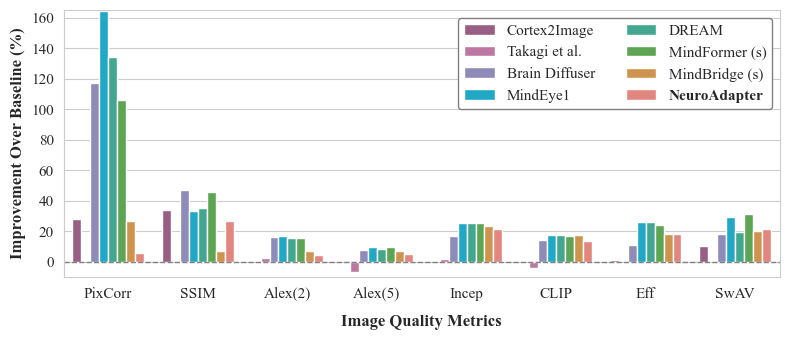

In [9]:
import pandas as pd
import seaborn as sns

import matplotlib as mpl
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Path to your font folder
font_dir = "/engram/nklab/pf2477/other/font/"

# Register all fonts in that folder
for font in os.listdir(font_dir):
    if font.startswith("Times New Roman"):
        print("Adding font:", font)
        fm.fontManager.addfont(os.path.join(font_dir, font))
        
plt.rcParams["font.family"] = "Times New Roman"
sns.set_style("whitegrid", {"grid.linestyle": "-", 'font.family':"Times New Roman"})
# Table data
data = {
    "Baseline": [0.117, 0.242, 80.98, 89.05, 74.62, 80.16, 0.872, 0.518],
    "Cortex2Image": [0.150, 0.325, None, None, None, None, 0.862, 0.465],
    # "Takagi & Nishimoto": [0.246, 0.410, 78.9, 85.6, 83.8, 82.1, 0.811, 0.504],
    "Takagi et al.": [None, None, 83.0, 83.0, 76.0, 77.0, None, None],
    # "Brain Diffuser": [0.273, 0.365, 94.4, 96.6, 91.3, 90.9, 0.728, 0.421],
    "Brain Diffuser": [0.254, 0.356, 94.2, 96.2, 87.2, 91.5, 0.775, 0.423],
    # "MindEye1": [0.319, 0.360, 92.8, 96.9, 94.6, 93.3, 0.648, 0.377],
    "MindEye1": [0.309, 0.323, 94.7, 97.8, 93.8, 94.1, 0.645, 0.367],
    "DREAM": [0.274, 0.328, 93.9, 96.7, 93.4, 94.1, 0.645, 0.418],
    "MindFormer (s)": [0.241, 0.352, 93.5, 97.5, 93.5, 93.6, 0.659, 0.356],
    "MindBridge (s)": [0.148, 0.259, 86.9, 95.3, 92.2, 94.3, 0.713, 0.413],
    "NeuroAdapter": [0.124, 0.307, 84.75, 93.66, 90.87, 91.10, 0.715, 0.405],
}

metrics = ["PixCorr", "SSIM", "Alex(2)", "Alex(5)",
           "Incep", "CLIP", "Eff", "SwAV"]

df = pd.DataFrame(data, index=metrics)

# Compute percentage improvements vs Baseline
baseline = df["Baseline"]
improvements = (df.subtract(baseline, axis=0)
                  .div(baseline, axis=0) * 100)

# Flip sign for ↓ metrics
for m in ["Eff", "SwAV"]:
    improvements.loc[m] = (baseline.loc[m] - df.loc[m]) / baseline.loc[m] * 100

# Reshape for plotting
plot_df = improvements.drop(columns="Baseline").reset_index().melt(id_vars="index")
plot_df.columns = ["Metric", "Model", "Improvement (%)"]

# Plot
plt.figure(figsize=(8, 3.5))

# Custom color palette
custom_colors = ["#F27970", "#E3943A", "#54B345", "#32B897", 
                "#05B9E2", "#8983BF", "#C76DA2", "#A35487"][::-1]

sns.barplot(
    data=plot_df,
    x="Metric", y="Improvement (%)",
    hue="Model", palette=custom_colors
)

fs = 11  # font size

plt.axhline(0, color="grey", linestyle="--", linewidth=1)
plt.xticks(rotation=0, ha="center", fontsize=fs)
plt.yticks(fontsize=fs)
plt.ylim(-10, 165)
plt.xlabel("Image Quality Metrics", fontsize=12, weight="bold", labelpad=10)
plt.ylabel("Improvement Over Baseline (%)", fontsize=12, weight="bold")
# plt.title("Model improvements over baseline across metrics", fontsize=12, weight="bold")

plt.legend(loc="upper right", frameon=True, facecolor='white', edgecolor='gray', framealpha=1, fontsize=fs, ncol=2)

# Make NeuroAdapter bold in legend
legend = plt.gca().get_legend()
for text in legend.get_texts():
    if text.get_text() == 'NeuroAdapter':
        text.set_weight('bold')
        text.set_fontsize(fs)

plt.tight_layout()
import os
os.chdir("/engram/nklab/pf2477/brain_decoding/figures")
plt.savefig("metric_nsd_core.pdf", format="pdf", bbox_inches="tight")
plt.show()
# plt.close()


Adding font: Times New Roman Bold.ttf
Adding font: Times New Roman.ttf
Adding font: Times New Roman Bold Italic.ttf
Adding font: Times New Roman Italic.ttf


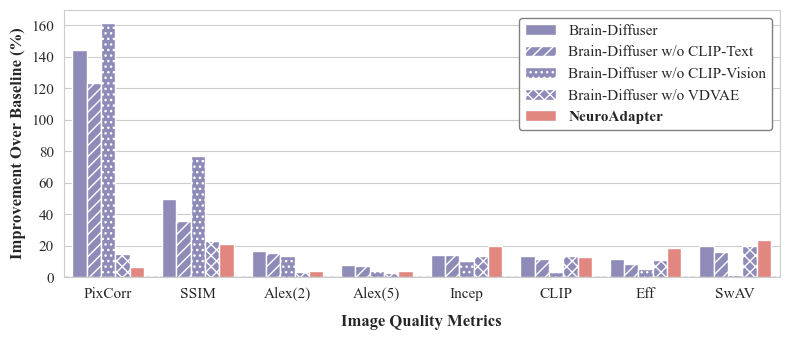

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import os

# Path to your font folder
font_dir = "/engram/nklab/pf2477/other/font/"

# Register all fonts in that folder
for font in os.listdir(font_dir):
    if font.startswith("Times New Roman"):
        print("Adding font:", font)
        fm.fontManager.addfont(os.path.join(font_dir, font))

plt.rcParams["font.family"] = "Times New Roman"
sns.set_style({'font.family': "Times New Roman"})

# ========================
# Table data
# ========================
data = {
    "Baseline": [0.125, 0.245, 82.88, 90.41, 76.98, 81.72, 0.868, 0.517],
    "Brain-Diffuser": [0.305, 0.367, 96.7, 97.4, 87.8, 92.5, 0.768, 0.415],
    "Brain-Diffuser w/o CLIP-Text": [0.279, 0.333, 95.6, 97.0, 87.9, 91.2, 0.796, 0.436],
    "Brain-Diffuser w/o CLIP-Vision": [0.327, 0.433, 93.9, 94.1, 84.7, 84.5, 0.821, 0.509],
    "Brain-Diffuser w/o VDVAE": [0.143, 0.302, 85.6, 93.0, 87.3, 92.6, 0.775, 0.414],
    "NeuroAdapter": [0.133, 0.296, 86.22, 93.96, 92.15, 92.03, 0.706, 0.396],
}

metrics = ["PixCorr", "SSIM", "Alex(2)", "Alex(5)",
           "Incep", "CLIP", "Eff", "SwAV"]

df = pd.DataFrame(data, index=metrics)

# ========================
# Compute improvements vs Baseline
# ========================
baseline = df["Baseline"]
improvements = (df.subtract(baseline, axis=0)
                  .div(baseline, axis=0) * 100)

# Flip sign for ↓ metrics
for m in ["Eff", "SwAV"]:
    improvements.loc[m] = (baseline.loc[m] - df.loc[m]) / baseline.loc[m] * 100

# Reshape for plotting
plot_df = improvements.drop(columns="Baseline").reset_index().melt(id_vars="index")
plot_df.columns = ["Metric", "Model", "Improvement (%)"]

# ========================
# Order of models and hatching
# ========================
model_order = [
    "Brain-Diffuser",
    "Brain-Diffuser w/o CLIP-Text",
    "Brain-Diffuser w/o CLIP-Vision",
    "Brain-Diffuser w/o VDVAE",
    "NeuroAdapter"
]

plot_df["Model"] = pd.Categorical(plot_df["Model"], categories=model_order, ordered=True)

hatches = ['', '///', '...', 'xxx','']
model2hatch = dict(zip(model_order, hatches))

# ========================
# Plotting
# ========================
plt.figure(figsize=(8, 3.5))

custom_colors = ["#8983BF", "#8983BF", "#8983BF", "#8983BF", "#F27970"]

ax = sns.barplot(
    data=plot_df,
    x="Metric", y="Improvement (%)",
    hue="Model", hue_order=model_order,
    palette=custom_colors
)

# Apply hatching correctly
for patch, model in zip(ax.patches, plot_df["Model"]):
    patch.set_hatch(model2hatch[model])

# ========================
# Styling
# ========================
fs = 11
plt.axhline(0, color="grey", linestyle="--", linewidth=1)
plt.xticks(rotation=0, ha="center", fontsize=fs)
plt.yticks(fontsize=fs)
plt.xlabel("Image Quality Metrics", fontsize=12, weight="bold", labelpad=10)
plt.ylabel("Improvement Over Baseline (%)", fontsize=12, weight="bold")
# plt.title("Model Improvements over baseline across metrics on Subject 1",
#           fontsize=12, weight="bold")

# Legend
legend = plt.legend(loc="upper right", frameon=True, facecolor='white',
                    edgecolor='gray', framealpha=1, fontsize=fs)

# Update legend patches with hatches
for text, patch in zip(legend.get_texts(), legend.get_patches()):
    model_name = text.get_text()
    if model_name == 'NeuroAdapter':
        text.set_weight('bold')
        text.set_fontsize(fs)
    patch.set_hatch(model2hatch.get(model_name, ''))

plt.tight_layout()
import os
os.chdir("/engram/nklab/pf2477/brain_decoding/figures")
plt.savefig("appendix_low_level_metric.pdf", format="pdf", bbox_inches="tight")
plt.show()
# plt.close()


Adding font: Times New Roman Bold.ttf
Adding font: Times New Roman.ttf
Adding font: Times New Roman Bold Italic.ttf
Adding font: Times New Roman Italic.ttf


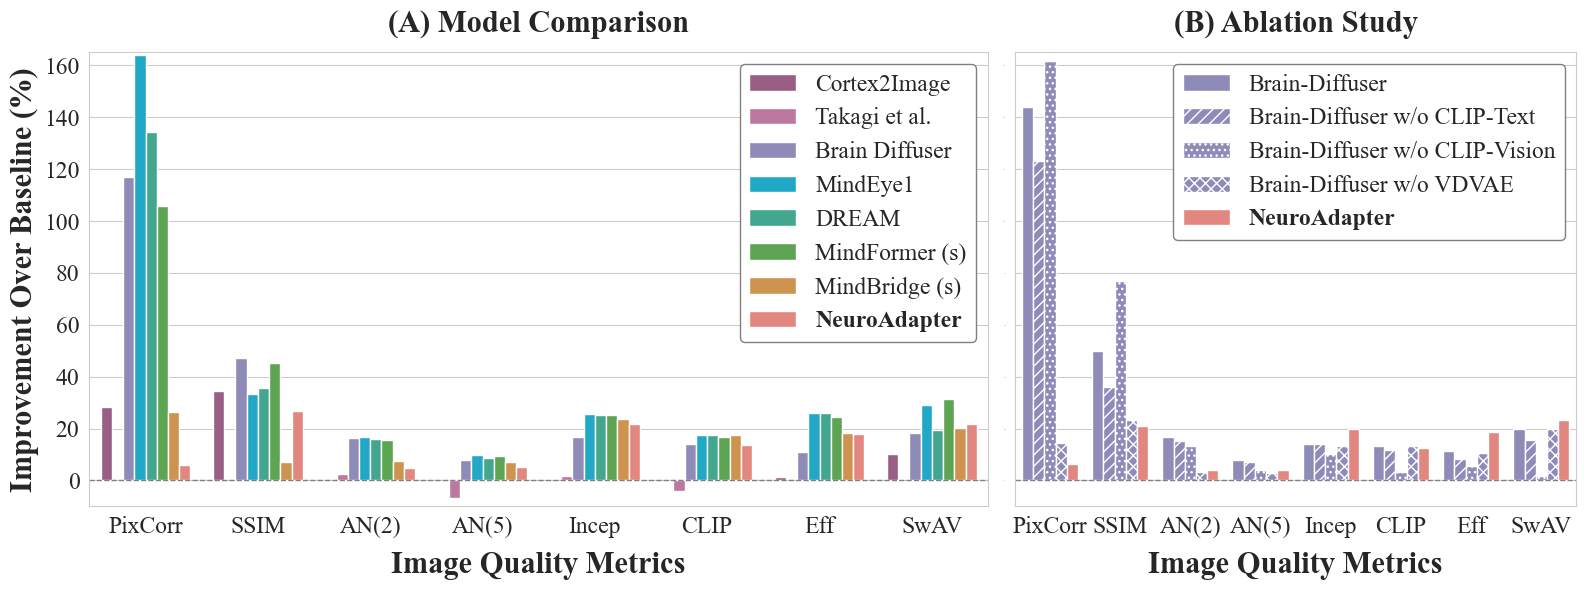

In [44]:
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import os

# Path to your font folder
font_dir = "/engram/nklab/pf2477/other/font/"

# Register all fonts in that folder
for font in os.listdir(font_dir):
    if font.startswith("Times New Roman"):
        print("Adding font:", font)
        fm.fontManager.addfont(os.path.join(font_dir, font))

plt.rcParams["font.family"] = "Times New Roman"
sns.set_style("whitegrid", {"grid.linestyle": "-", 'font.family':"Times New Roman"})

def plot_main_comparison(ax):
    # Main comparison data
    data = {
        "Baseline": [0.117, 0.242, 80.98, 89.05, 74.62, 80.16, 0.872, 0.518],
        "Cortex2Image": [0.150, 0.325, None, None, None, None, 0.862, 0.465],
        "Takagi et al.": [None, None, 83.0, 83.0, 76.0, 77.0, None, None],
        "Brain Diffuser": [0.254, 0.356, 94.2, 96.2, 87.2, 91.5, 0.775, 0.423],
        "MindEye1": [0.309, 0.323, 94.7, 97.8, 93.8, 94.1, 0.645, 0.367],
        "DREAM": [0.274, 0.328, 93.9, 96.7, 93.4, 94.1, 0.645, 0.418],
        "MindFormer (s)": [0.241, 0.352, 93.5, 97.5, 93.5, 93.6, 0.659, 0.356],
        "MindBridge (s)": [0.148, 0.259, 86.9, 95.3, 92.2, 94.3, 0.713, 0.413],
        "NeuroAdapter": [0.124, 0.307, 84.75, 93.66, 90.87, 91.10, 0.715, 0.405],
    }
    
    metrics = ["PixCorr", "SSIM", "AN(2)", "AN(5)", "Incep", "CLIP", "Eff", "SwAV"]
    df = pd.DataFrame(data, index=metrics)
    
    # Compute improvements
    baseline = df["Baseline"]
    improvements = (df.subtract(baseline, axis=0).div(baseline, axis=0) * 100)
    
    # Flip sign for ↓ metrics
    for m in ["Eff", "SwAV"]:
        improvements.loc[m] = (baseline.loc[m] - df.loc[m]) / baseline.loc[m] * 100
    
    plot_df = improvements.drop(columns="Baseline").reset_index().melt(id_vars="index")
    plot_df.columns = ["Metric", "Model", "Improvement (%)"]
    
    custom_colors = ["#F27970", "#E3943A", "#54B345", "#32B897", 
                    "#05B9E2", "#8983BF", "#C76DA2", "#A35487"][::-1]
    
    sns.barplot(data=plot_df, x="Metric", y="Improvement (%)", 
                hue="Model", palette=custom_colors, ax=ax)
    
    fs = 17
    offset=5
    ax.axhline(0, color="grey", linestyle="--", linewidth=1)
    ax.set_ylim(-10, 165)
    ax.set_xlabel("Image Quality Metrics", fontsize=fs+offset, weight="bold", labelpad=10)
    ax.set_ylabel("Improvement Over Baseline (%)", fontsize=fs+offset, weight="bold")
    ax.tick_params(axis='both', labelsize=fs)
    
    legend = ax.legend(loc="upper right", frameon=True, facecolor='white', 
                      edgecolor='gray', framealpha=1, fontsize=fs, ncol=1)
    for text in legend.get_texts():
        if text.get_text() == 'NeuroAdapter':
            text.set_weight('bold')
    
    ax.set_title("(A) Model Comparison", fontsize=fs+offset, weight="bold", pad=15)

def plot_ablation_study(ax):
    # Ablation study data
    data = {
        "Baseline": [0.125, 0.245, 82.88, 90.41, 76.98, 81.72, 0.868, 0.517],
        "Brain-Diffuser": [0.305, 0.367, 96.7, 97.4, 87.8, 92.5, 0.768, 0.415],
        "Brain-Diffuser w/o CLIP-Text": [0.279, 0.333, 95.6, 97.0, 87.9, 91.2, 0.796, 0.436],
        "Brain-Diffuser w/o CLIP-Vision": [0.327, 0.433, 93.9, 94.1, 84.7, 84.5, 0.821, 0.509],
        "Brain-Diffuser w/o VDVAE": [0.143, 0.302, 85.6, 93.0, 87.3, 92.6, 0.775, 0.414],
        "NeuroAdapter": [0.133, 0.296, 86.22, 93.96, 92.15, 92.03, 0.706, 0.396],
    }
    
    metrics = ["PixCorr", "SSIM", "AN(2)", "AN(5)", "Incep", "CLIP", "Eff", "SwAV"]
    df = pd.DataFrame(data, index=metrics)
    
    baseline = df["Baseline"]
    improvements = (df.subtract(baseline, axis=0).div(baseline, axis=0) * 100)
    
    for m in ["Eff", "SwAV"]:
        improvements.loc[m] = (baseline.loc[m] - df.loc[m]) / baseline.loc[m] * 100
    
    plot_df = improvements.drop(columns="Baseline").reset_index().melt(id_vars="index")
    plot_df.columns = ["Metric", "Model", "Improvement (%)"]
    
    model_order = ["Brain-Diffuser", "Brain-Diffuser w/o CLIP-Text", 
                   "Brain-Diffuser w/o CLIP-Vision", "Brain-Diffuser w/o VDVAE", "NeuroAdapter"]
    plot_df["Model"] = pd.Categorical(plot_df["Model"], categories=model_order, ordered=True)
    
    custom_colors = ["#8983BF", "#8983BF", "#8983BF", "#8983BF", "#F27970"]
    hatches = ['', '///', '...', 'xxx','']
    model2hatch = dict(zip(model_order, hatches))
    
    sns.barplot(data=plot_df, x="Metric", y="Improvement (%)", 
                hue="Model", hue_order=model_order, palette=custom_colors, ax=ax)
    
    # Apply hatching
    for patch, model in zip(ax.patches, plot_df["Model"]):
        patch.set_hatch(model2hatch[model])
    
    fs = 17
    offset = 5
    ax.axhline(0, color="grey", linestyle="--", linewidth=1)
    ax.set_xlabel("Image Quality Metrics", fontsize=fs+offset, weight="bold", labelpad=10)
    ax.tick_params(axis='x', labelsize=fs)
    ax.tick_params(axis='y', labelsize=0)  # Hide y-axis tick labels
    ax.set_ylim(-10, 165)
    ax.set_ylabel("")  # Remove y-axis label for the second plot
    
    legend = ax.legend(loc="upper right", frameon=True, facecolor='white',
                      edgecolor='gray', framealpha=1, fontsize=fs)
    
    for text, patch in zip(legend.get_texts(), legend.get_patches()):
        model_name = text.get_text()
        if model_name == 'NeuroAdapter':
            text.set_weight('bold')
        patch.set_hatch(model2hatch.get(model_name, ''))
    
    ax.set_title("(B) Ablation Study", fontsize=fs+offset, weight="bold", pad=15)

# Create combined figure with 8:5 width ratio
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'width_ratios': [8, 5]})

plot_main_comparison(ax1)
plot_ablation_study(ax2)

plt.tight_layout()

os.chdir("/engram/nklab/pf2477/brain_decoding/figures")
plt.savefig("combined_metrics.pdf", format="pdf", bbox_inches="tight")
plt.show()